## Tarea 1 DAML 2026

### Vicente Esteban Díaz Torres
### 2021444521

#### Analisis de los datos

#### Importar librerias

In [1]:
# Probado en Python 3.13.9
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns                      
import missingno as msno                   #Muestra los datos vacios de cada variable
import statsmodels.api as sm
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer  #Biblioteca que permite tabular resultados para comparar
from IPython.core.display import HTML      #Habilita una mejora visual a las tablas de stargazer
import warnings
warnings.filterwarnings('ignore')

#### Cargamos la base de datos

In [2]:

# 1. Cargar base de datos
df = pd.read_csv("student_productivity.csv")
data = df.copy()  

print(" Dimensiones iniciales:", {data.shape})
print(data.info())


 Dimensiones iniciales: {(5621, 22)}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5621 entries, 0 to 5620
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5621 non-null   int64  
 1   age                   4973 non-null   float64
 2   gender                5063 non-null   object 
 3   academic_level        4991 non-null   object 
 4   study_hours           5047 non-null   float64
 5   self_study_hours      4954 non-null   float64
 6   online_classes_hours  4939 non-null   float64
 7   social_media_hours    4965 non-null   float64
 8   gaming_hours          4965 non-null   float64
 9   sleep_hours           5068 non-null   float64
 10  screen_time_hours     5035 non-null   float64
 11  exercise_minutes      5022 non-null   object 
 12  caffeine_intake_mg    5021 non-null   float64
 13  part_time_job         4918 non-null   object 
 14  upcoming_deadline     4904 non-null

#### Visualizamos los algunos datos segun su tipo

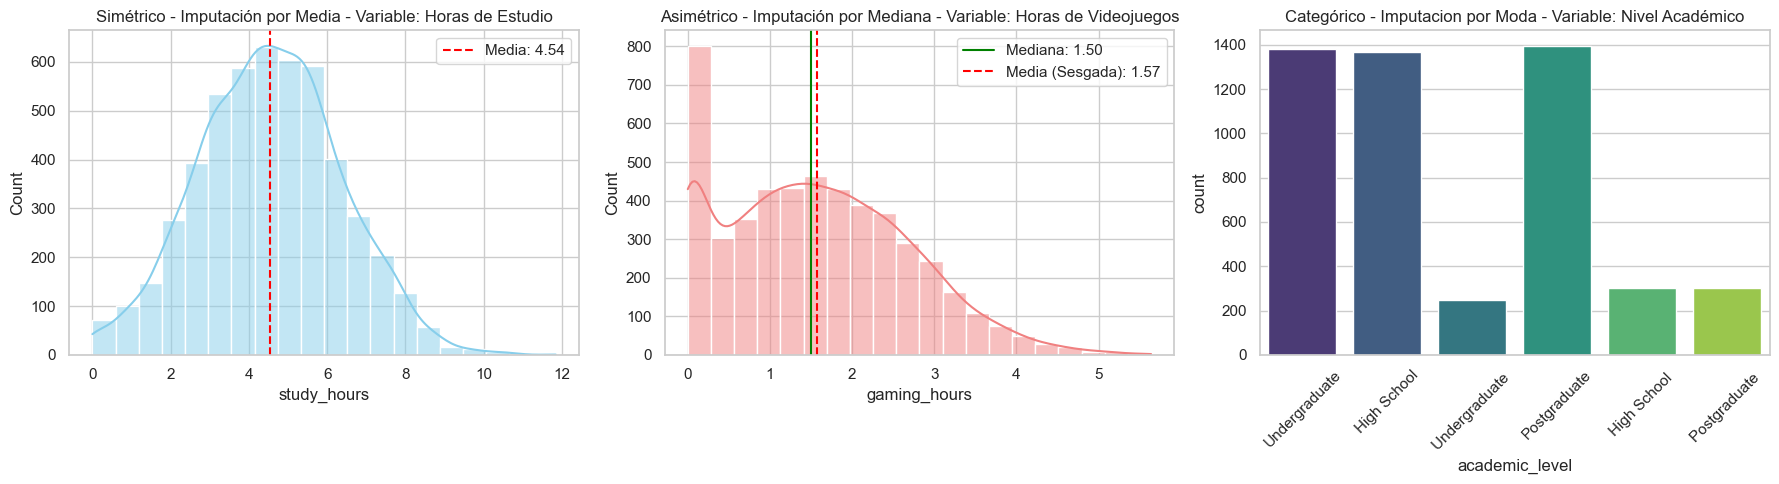

In [3]:
# Configuramos el estilo y tamaño general de los gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# 1. Gráfico para justificar la imputación por MEDIA (Distribución Simétrica)
# study_hours tiene forma de campana (normal), el promedio está justo en el centro.
sns.histplot(df['study_hours'].dropna(), kde=True, color="skyblue", bins=20, ax=axes[0])
axes[0].axvline(df['study_hours'].mean(), color='red', linestyle='--', label=f'Media: {df["study_hours"].mean():.2f}')
axes[0].set_title("Simétrico - Imputación por Media - Variable: Horas de Estudio")
axes[0].legend()
# 2. Gráfico para justificar la imputación por MEDIANA (Asimetría y Outliers)
# gaming_hours está sesgado (la mayoría juega poco), con valores atípicos altos.
sns.histplot(df['gaming_hours'].dropna(), kde=True, color="lightcoral", bins=20, ax=axes[1])
axes[1].axvline(df['gaming_hours'].median(), color='green', linestyle='-', label=f'Mediana: {df["gaming_hours"].median():.2f}')
axes[1].axvline(df['gaming_hours'].mean(), color='red', linestyle='--', label=f'Media (Sesgada): {df["gaming_hours"].mean():.2f}')
axes[1].set_title("Asimétrico - Imputación por Mediana - Variable: Horas de Videojuegos")
axes[1].legend()
# 3. Gráfico para justificar imputación por MODA (Variables Categóricas/Texto)
# academic_level no es matemático, por lo que rellenamos categóricamente con la opción más alta.
sns.countplot(data=df, x='academic_level', palette="viridis", ax=axes[2])
axes[2].set_title("Categórico - Imputacion por Moda - Variable: Nivel Académico")
axes[2].tick_params(axis='x', rotation=45) # Gira el texto para que se lea mejor
# Ajustar los gráficos para que no se sobrepongan
plt.tight_layout()
plt.show()

#### Parte 1. Limpieza de datos

Dimensiones luego de limpieza: {(4994, 23)}
student_id               0
age                      0
gender                  76
academic_level           0
study_hours              0
self_study_hours         0
online_classes_hours     0
social_media_hours       0
gaming_hours             0
sleep_hours              0
screen_time_hours        0
exercise_minutes         0
caffeine_intake_mg       0
part_time_job            0
upcoming_deadline        0
internet_quality         0
mental_health_score      0
focus_index              0
burnout_level            0
productivity_score       0
exam_score               0
part_time_job_Y_N        0
rindio_examen            0
dtype: int64


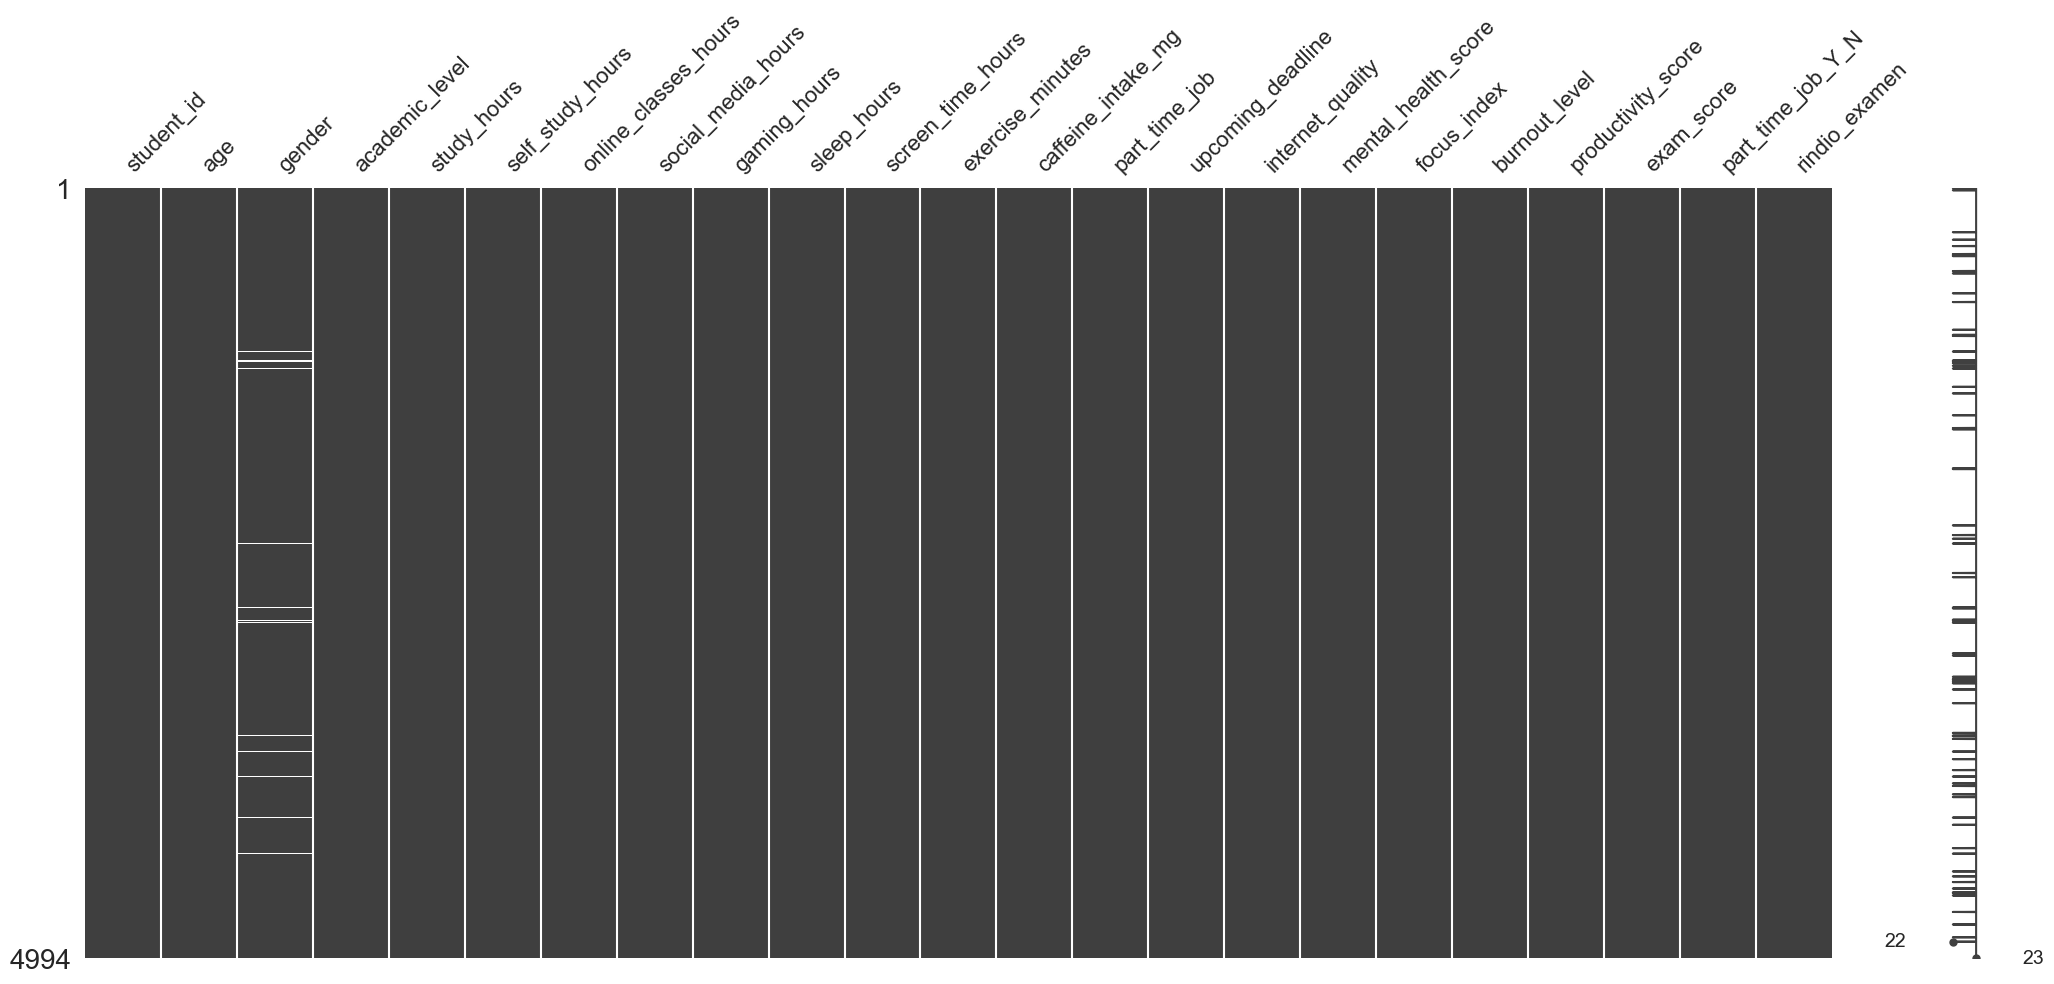

In [4]:

# Limpieza de datos

# Eliminamos la columna drug_use por tener demasiados nulos para ser imputable (>70% NAs)
data.drop('drug_use', axis=1, inplace=True, errors='ignore')

# Eliminamos filas que estén abismalmente vacías (algunas filas que tienen pocos datos faltantes pueden servir para explicar otras variables)
data.dropna(thresh=data.shape[1]-6, inplace=True)

# Estrategia de Imputación: Media para simétricas, Mediana para asimétricas y Moda para Categóricas
columnas_media = ['age', 'study_hours', 'self_study_hours', 'online_classes_hours', 'sleep_hours', 'screen_time_hours', 'focus_index', 'burnout_level']
for col in columnas_media:
    data[col].fillna(round(data[col].mean(), 2), inplace=True)

columnas_mediana = ['social_media_hours', 'caffeine_intake_mg', 'mental_health_score', 'productivity_score', 'exam_score', 'gaming_hours']
for col in columnas_mediana:
    data[col].fillna(round(data[col].median(), 2), inplace=True)

# Imputación de moda
data['upcoming_deadline'].fillna(data['upcoming_deadline'].mode()[0], inplace=True)
data['internet_quality'].fillna(data['internet_quality'].mode()[0], inplace=True)
data['academic_level'] = data['academic_level'].str.strip()
data['academic_level'].fillna(data['academic_level'].mode()[0], inplace=True)

# Limpieza de exercise_minutes (extracción de números)
data['exercise_minutes'] = data['exercise_minutes'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)
data['exercise_minutes'].fillna(data['exercise_minutes'].median(), inplace=True)

# Normalizar part_time_job a variables Dummy numéricas
data["part_time_job"] = data["part_time_job"].astype(str).replace('nan', pd.NA).str.capitalize()
data["part_time_job"].fillna(data["part_time_job"].mode()[0], inplace=True)
data['part_time_job_Y_N'] = data['part_time_job'].map({'Yes': 1, 'No': 0}).astype(int)

# Transformaciones de re-escalado e índices
data['productivity_score'] = data['productivity_score'] / 10
data['burnout_level'] = data['burnout_level'] / 10
data['focus_index'] = data['focus_index'] / 10
data['age'] = data['age'].apply(np.trunc)

# Variable binaria  (Si la nota  es > 1.0 rindió el examen)
data["rindio_examen"] = np.where(data['exam_score'] > 1.0, 1, 0)

print("Dimensiones luego de limpieza:", {data.shape})
print(data.isnull().sum())
msno.matrix(data)
plt.show()

#### Criterios utilizados:
- La variable "drug_use" es eliminada por poseer demasiados valores nulos, eliminar las filas nulas implicaria la perdida de valiosa información explicativa de las otras variables.

- Para no perder datos, se han rellenado algunas filas con NA. 

- Para las columnas, 'age', 'study_hours', 'self_study_hours', 
'online_classes_hours', 'sleep_hours', 'screen_time_hours', 'focus_index', 'burnout_level', se ha obtenido la media y se han rellenado. La razon de esto, es porque estas variables se comportan de manera simetrica y continua, cumpliendo con una distribucion normal. Un ejemplo de esto es que al visualizar la data, se puede observar la mayor cantidad de datos entre intervalos, como la edad entre 18-24 años o las horas de sueño entre 6 y 8.

- Las variables 'social_media_hours', 'caffeine_intake_mg', 'mental_health_score', 'productivity_score', 'exam_score', 'gaming_hours', se han rellenado con la mediana, ya que al ver los datos existen variabilidad entre ellos, por tanto la media se puede desviar por datos extremos. 

- Las otras variables como 'upcoming_deadline', 'internet_quality', 'academic_level', 'academic_level', se ha rellenado usando la Moda, es decir el dato mas frecuente.

De esta forma, se puede garantizar mantener la cantidad de la muestra para permitir mejores resultados en los modelos de probabilidad.


#### Parte 2. Ejecute un modelo de probabilidad lineal (*MCO*) que permita explicar la probabilidad de que un alumno rinda el examen, a partir de las informacion disponible. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado.

In [5]:

#Planteamos una fórmula diferenciada incluyendo interacciones analíticas
# study_hours:sleep_hours nos permite evaluar la relación conjunta de horas de estudio con sueño
# social_media_hours:focus_index mide el impacto cruzado entre concentración y redes sociales
formula_bin = 'rindio_examen ~ productivity_score + burnout_level  + study_hours:focus_index + social_media_hours:focus_index + exercise_minutes:mental_health_score'
 
# Modelo Probabilidad Lineal MCO con errores estándar robustos HC1
modelo_ols = smf.ols(formula_bin, data=data).fit(cov_type='HC1')
print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:          rindio_examen   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     142.0
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          2.72e-141
Time:                        16:27:26   Log-Likelihood:                -73.052
No. Observations:                4994   AIC:                             158.1
Df Residuals:                    4988   BIC:                             197.2
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------



- La variable 'productivity_score' tiene un coeficiente positivo, lo que implica que un aumento de puntuacion de productividad incrementa en un 9,2% de rendir mejor en el examen.

- La variable 'burnout_level' tiene un coeficiente negativo , implica que un aumento del nivel de burnout impacta negativamente en un 1,7% el rendimiento de un examen.

- La interración entre horas de estudio y el nivel de concentración, entrega que afecta negativamente en un 0,39% el rendimiento del examen, lo cual es bastante extraño ya que generalmente estudiar mucho tiempo con un nivel de concentracion deberia prepararte mejor, por tanto, puede ser que prolongados tiempos de estudio con una alta concentracion generen fatiga mental que podria explicar estos resultados.

- La interración entre horas en redes sociales y nivel de concentracion, entrega un valor positivo en el coeficiente de 0,2%, esto evidencia matemáticamente que el uso de redes sociales, cuando está estrechamente emparejado con un alto índice de atención del alumno, no funciona como un factor perjudicial, sino como un catalizador positivo en la probabilidad de rendir la prueba. Esto se podria explicar, que los mejores alumnos utilizan las redes sociales como una herramienta eficeinte de pausa activa.

- En la interacción entre minuros de ejercicio y salud mental, afecta negativamente pero es un coeficiente muy pequeño, se podria decir que no afecta en casi nada el rendimiento del examen.

#### Parte 3. Ejecute un modelo *probit* para responder a la pregunta 2. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado.

In [6]:
# Modelo Probit con cálculo de Efectos Marginales para su interpretación correcta
modelo_probit = smf.probit(formula_bin, data=data).fit(cov_type='HC1')
print(modelo_probit.summary())

print("--- EFECTOS MARGINALES PROBIT ---")
mfx_probit = modelo_probit.get_margeff()
print(mfx_probit.summary())

Optimization terminated successfully.
         Current function value: 0.134560
         Iterations 9
                          Probit Regression Results                           
Dep. Variable:          rindio_examen   No. Observations:                 4994
Model:                         Probit   Df Residuals:                     4988
Method:                           MLE   Df Model:                            5
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.5436
Time:                        16:27:26   Log-Likelihood:                -671.99
converged:                       True   LL-Null:                       -1472.5
Covariance Type:                  HC1   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                                0.1898      0.1

- Valor de pseudo R cuadrado es de 0,5436, lo cual es un valor bueno para modelos probabilísticos, es decir que las variables explican un 54,3% de los datos.

- Al usar los efectos marginales, permite analizar correctamente los coeficientes de modelo probit, ya que entregaban valores engañosos.

- Revisando los coeficientes obtenidos de forma marginal, se tienen cambios ne relacion al MCO, como por ejemplo que ahora afecta positivamente la interaccion study_hours:focus_index, indicando que se corrige la desicion tomada por el modelo anterior. 

- La interaccion exercise_minutes:mental_health_score se tiene un valor p mayor a 0,05 por tanto se rechazaria en que incida en la decision de rendir en el test.

#### Parte 4. Ejecute un modelo *logit* para responder a la pregunta 2. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado.

In [7]:
#Modelo Logit con cálculo de Efectos Marginales
modelo_logit = smf.logit(formula_bin, data=data).fit(cov_type='HC1')
print(modelo_logit.summary())

print("--- EFECTOS MARGINALES LOGIT ---")
mfx_logit = modelo_logit.get_margeff()
print(mfx_logit.summary())

Optimization terminated successfully.
         Current function value: 0.134670
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:          rindio_examen   No. Observations:                 4994
Model:                          Logit   Df Residuals:                     4988
Method:                           MLE   Df Model:                            5
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.5433
Time:                        16:27:26   Log-Likelihood:                -672.54
converged:                       True   LL-Null:                       -1472.5
Covariance Type:                  HC1   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                                0.2290      0.3

- El pseudo R-cuadrado es igual al probit, lo que indicaria que la elección algorítmica es consistente.

- productivity_score con un dy/dx de 0,0702 Las chances base ("odds ratio") que entrega Logit suben radicalmente impulsadas por la productividad. No obstante, al limpiar su lectura en efecto marginal, Logit valida la hipótesis anterior estimando un salto en 7,02% de dar la prueba por cada unidad de mejora (muy parecido al 6,81% entregado por Probit).


#### Parte 5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

In [8]:
# Tabla Comparativa mediante Stargazer para una visualización profesional
stargazer = Stargazer([modelo_ols, modelo_probit, modelo_logit])
stargazer.custom_columns(["MCO", "Probit", "Logit"], [1, 1, 1])
stargazer.title("Comparación de Modelos de Probabilidad de Rendir Examen")
HTML(stargazer.render_html())
#Realizamos una comparatriva con los mdelos anteriores para ver cual es el mejor modelo para predecir si un estudiante aprueba o no el examen (Exam) utilizando las variables numéricas seleccionadas.
#Para comparar los modelos, podemos usar el AIC (Akaike Information Criterion) y el BIC (Bayesian Information Criterion) que son medidas de la calidad del modelo penalizadas por el número de parámetros. El modelo con el menor AIC y BIC es generalmente considerado el mejor.
print("Comparativa de Modelos:")
print(f"Modelo OLS: AIC = {modelo_ols.aic:.2f}, BIC = {modelo_ols.bic:.2f}")
print(f"Modelo Logit: AIC = {modelo_logit.aic:.2f}, BIC = {modelo_logit.bic:.2f}")
print(f"Modelo Probit: AIC = {modelo_probit.aic:.2f}, BIC = {modelo_probit.bic:.2f}")


Comparativa de Modelos:
Modelo OLS: AIC = 158.10, BIC = 197.20
Modelo Logit: AIC = 1357.08, BIC = 1396.18
Modelo Probit: AIC = 1355.98, BIC = 1395.08


- Entre estas tres formas, definitivamente Probit y Logit por sobre MCO. El modelo MCO de "Probabilidad Lineal" asume un impacto constante y lineal, provocando riesgo de entregar estimaciones fuera del rango lógico de 0 a 100%. Probit o Logit asumen una distribución acumulativa y son metodológicamente correctos para clasificación binaria. Logit suele ser levemente preferido dado que sus colas de distribución son ligeramente más gruesas, lidiando un poco mejor con los outliers si los hay.

- Son robustas aquellas variables que independientemente de si usamos MCO, Probit o Logit siguen incidiendo significativamente en la misma dirección y aportando capacidad predictiva. Estas son productivity_score (afecta positivamente) y burnout_level (afecta negativamente ). La interacción de horas de redes sociales junto a concentración (social_media_hours:focus_index) también demuestra robustez positiva en Probit y Logit.

#### Parte 6. Use un modelo Poisson para explicar la nota del examen, entre aquellos alumnos que lo rindieron. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado.

In [9]:
# Filtramos solo aquellos alumnos que rindieron el examen (rindio_examen == 1
data_examen = data[data['rindio_examen'] == 1].copy()
data_examen['exam_score_int'] = data_examen['exam_score'].round().astype(int)
data_examen['exercise_hours'] = data_examen['exercise_minutes'] / 60.0

# Utilizamos exactamente la misma formulación de covariables para el modelo de conteo
formula_count =  'exam_score_int ~ productivity_score + burnout_level + study_hours:focus_index + social_media_hours:focus_index + exercise_hours:mental_health_score'


modelo_poisson = smf.poisson(formula_count, data=data_examen).fit(cov_type='HC1')
data_examen['ppredictions'] = modelo_poisson.predict(data_examen).astype(float)
print(modelo_poisson.summary())

Optimization terminated successfully.
         Current function value: 3.342609
         Iterations 5
                          Poisson Regression Results                          
Dep. Variable:         exam_score_int   No. Observations:                 4561
Model:                        Poisson   Df Residuals:                     4555
Method:                           MLE   Df Model:                            5
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.3912
Time:                        16:27:26   Log-Likelihood:                -15246.
converged:                       True   LL-Null:                       -25044.
Covariance Type:                  HC1   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                              2.1882      0.024    

- El modelo nos arroja que las variables individuales siguen un mismo patrón de intuición de los modelos probabilísticos. Específicamente, el productivity_score tiene un coeficiente positivo de 0,2498, es decir, subir tu score de productividad en una unidad aumenta el rendimiento en la nota aproximadamente un 25% (al tratarse de variaciones de logaritmos en Poisson). Por otro lado, la variable de agotamiento burnout_level afecta fuerte y negativamente (-0,0764, restando un 7,6% del rendimiento esperado). El uso de horas extra combinadas (exercise_hours:mental_health_score) se vuelve muy significativo en contribuir al alza de notas.

#### Parte 7. Determine si existe sobre dispersion en la data y posible valor optimo de alpha para un modelo Binomial Negativa.

In [10]:
#Regresión Auxiliar Rigurosa para estimar Sobredispersión y predecir el óptimo de Alpha

# Variable aux = ((y - lambda)^2 - lambda) / lambda
aux = ((data_examen['exam_score'] - data_examen['ppredictions'])**2 - data_examen['ppredictions']) / data_examen['ppredictions']

# Regresión de aux vs predictor ppredictions (lambda) sin constante
auxr = sm.OLS(aux, data_examen['ppredictions']).fit()

print(auxr.summary())

alpha_estimado = auxr.params.iloc[0]
print(f"Valor Óptimo Estimado de Alpha: {alpha_estimado}")
if alpha_estimado > 0:
    print("Existe evidencia robusta estadísticamente de sobre-dispersión (Alpha > 0), lo cual justifica el uso futuro del modelo Binomial.")



                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.050
Model:                            OLS   Adj. R-squared (uncentered):              0.050
Method:                 Least Squares   F-statistic:                              241.1
Date:                Tue, 21 Apr 2026   Prob (F-statistic):                    5.06e-53
Time:                        16:27:26   Log-Likelihood:                         -11306.
No. Observations:                4561   AIC:                                  2.261e+04
Df Residuals:                    4560   BIC:                                  2.262e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

- Para que el modelo Poisson de la Parte 6 sea completamente válido como supuestos econométricos, la Varianza de las notas tiene que ser idéntica a su Media (Varianza = Media). Si hacemos la regresión auxiliar para testear este supuesto a través del modelo cuadrado de los residuos , el resultado nos confirma estadísticamente que existe un estimado Alpha ($ \alpha $) fuertemente positivo y significativo (+0.029).

- Al rechazar la hipótesis nula y encontrar este valor altamente desviado de cero (se avalan por $P>|t|$ = 0,000), confirmamos la existencia de un claro problema de sobredispersión. Esto justifica fehacientemente correr un modelo Binomial Negativo en la siguiente etapa.

#### Parte 8. Usando la informacion anterior, ejecute un modelo Binomial Negativa para responder a la pregunta 6. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado.

In [11]:
#Mantenemos las mismas covariables (formula_count) para poder comparar el impacto ceteris paribus aislando Alpha
modelo_nb = smf.negativebinomial(formula_count, data=data_examen).fit(method='bfgs', maxiter=300)
print(modelo_nb.summary())

Optimization terminated successfully.
         Current function value: 3.242973
         Iterations: 19
         Function evaluations: 27
         Gradient evaluations: 27
                     NegativeBinomial Regression Results                      
Dep. Variable:         exam_score_int   No. Observations:                 4561
Model:               NegativeBinomial   Df Residuals:                     4555
Method:                           MLE   Df Model:                            5
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.1469
Time:                        16:27:26   Log-Likelihood:                -14791.
converged:                       True   LL-Null:                       -17338.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------

- Este modelo relaja el estricto supuesto de varianza asumiendo la dispersión antes encontrada. La variable iterada alpha interna de statsmodels corrobora la sobredispersión entregándonos de nuevo un resultado con fuerte significancia estadística (coeficiente $\alpha$ interno = 0,0446, p-value = 0,000). A nivel de las predicciones, los coeficientes rectificaron leves magnitudes con respecto al modelo de Poisson; productivity_score pasó de +0,249 a +0,258, y burnout_level de -0,076 a -0,084.

#### Parte 9. Comente los resultados obtenidos en 6, 7 y 8. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

In [12]:
stargazer2 = Stargazer([modelo_poisson, modelo_nb])
stargazer2.custom_columns(["Poisson", "Binomial Negativa"], [1, 1])
stargazer2.title("Comparación Modelos de Conteo (Puntaje del Examen)")
HTML(stargazer2.render_html())

- Pese a que los coeficientes entre Poisson y Binomial Negativo se pueden interpretar de forma similar (el burnout es malo; la productividad es buena), la principal diferencia recae en sus errores estándar. El Poisson no lidia con la sobredispersión, por ende infla sus ratios artificialmente (generando potenciales "falsos positivos" al subestimar sus márgenes de error). En la Regresión Auxiliar vimos esta falla validada numéricamente de manera irrefutable.

- El modelo mas adecuado es totalmente el modelo Binomial Negativo. En datos del mundo real como lo es el rendimiento educativo, casi siempre hay variación de varianzas sin la rigidez de media constante que demanda Poisson. El Binomial Negativo previene el ser víctimas de sesgos y no sobredimensiona los resultados en la población general.

- Las variables robustas fueron productivity_score, burnout_level, y la interacción study_hours:focus_index sobrevivieron todos los tests e incluso superando la limpieza de los Errores Estándar que aplicó el modelo de Binomial Negativo sobre su antecesor Poisson. La interacción de social_media_hours:focus_index resulta ser falsa y no es robusta (fue eliminada como no-significativa a p-value alrededor de 0.31 en ambos modelos de nota, pese a que en la probalidad de simplemente "rendir" sí era útil).